# Assignment 10 — Clustering: Wholesale Customer Segmentation

**Objective:** Perform customer segmentation on the UCI Wholesale Customers dataset using clustering techniques.
**Dataset:** 440 customers, 8 features (Channel, Region, and 6 annual spending categories).

## 0 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


---
## 1 — Data Loading & Inspection

In [2]:
df = pd.read_csv('Wholesale_customers_data.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
df.describe().round(1)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0,440.0,440.0
mean,1.3,2.5,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,0.5,0.8,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
25%,1.0,2.0,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,1.0,3.0,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,2.0,3.0,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


---
## 2 — Exploratory Data Analysis (EDA)

### 2.1 Distribution of Spending Features

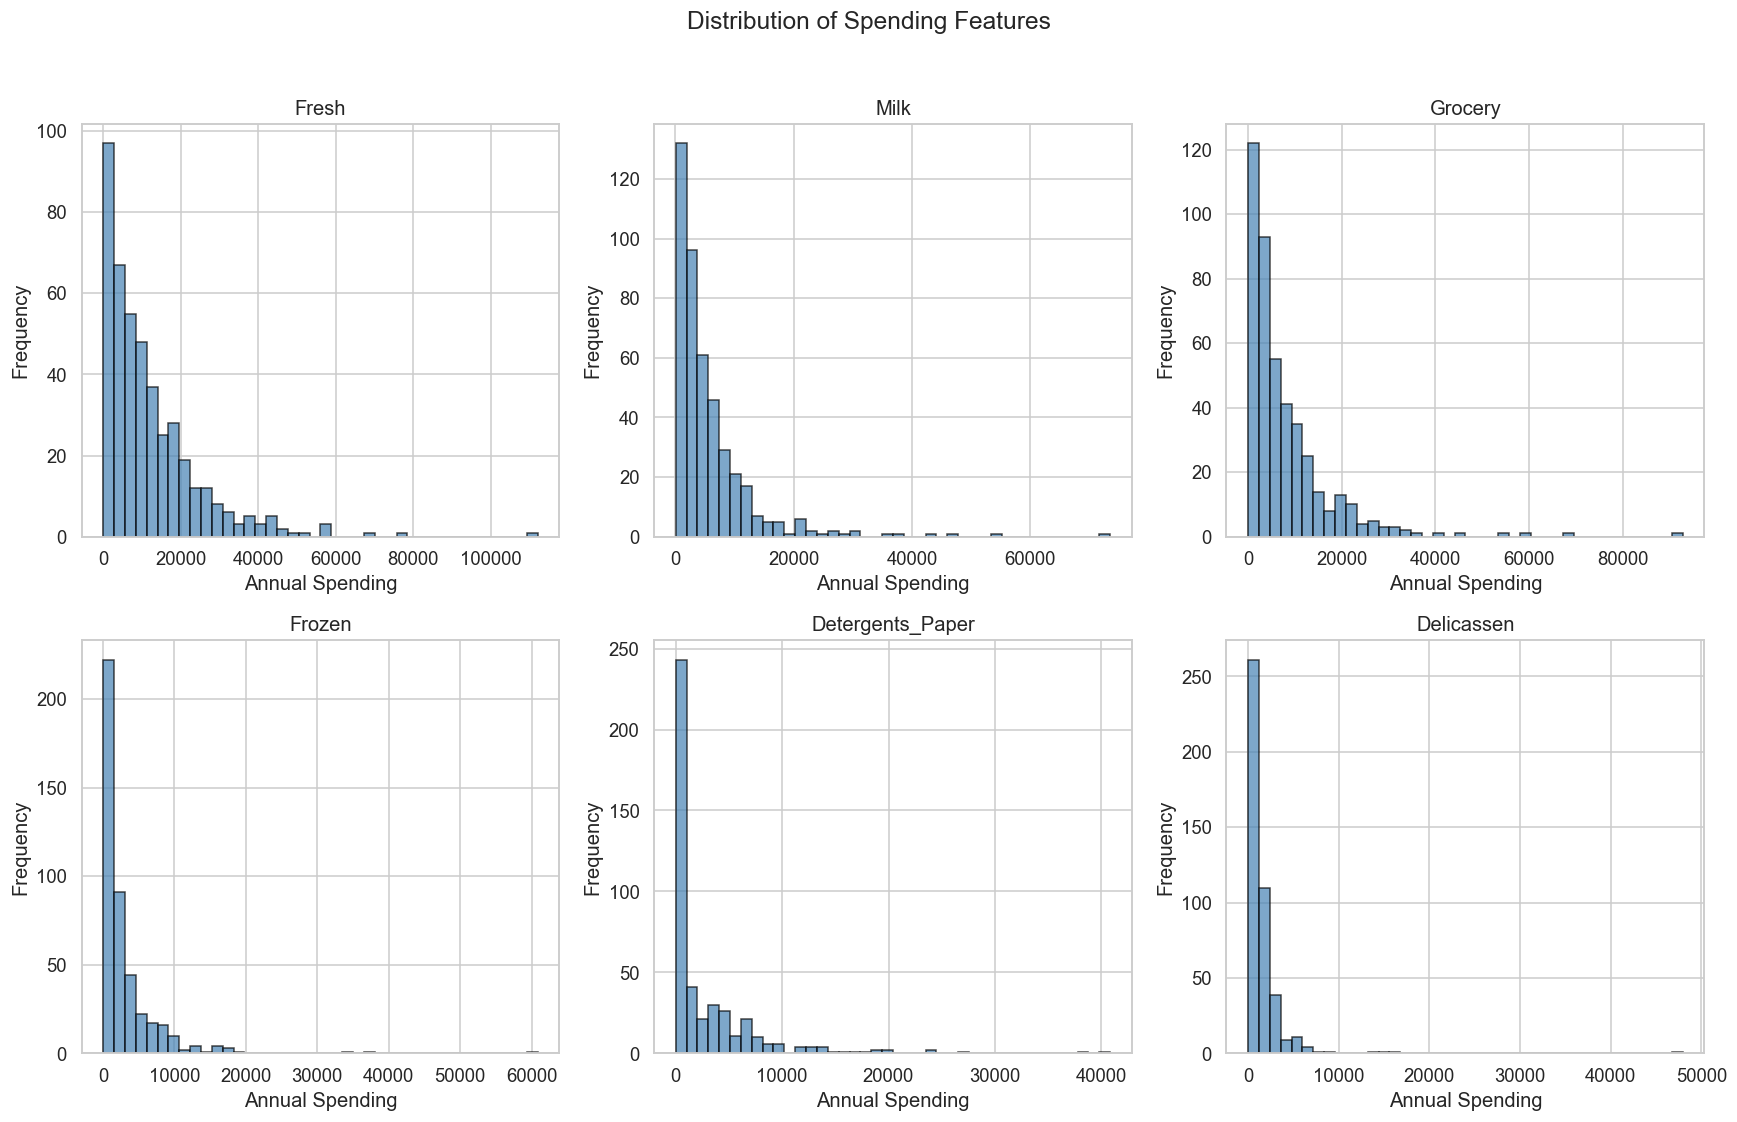

In [6]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(spending_cols):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Annual Spending')
    ax.set_ylabel('Frequency')
plt.suptitle('Distribution of Spending Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
print('Skewness of spending features:')
print(df[spending_cols].skew().round(2))

Skewness of spending features:
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64


**Observation:** All six spending features are heavily right-skewed (skewness ranging from ~2.5 to ~11), with many upper outliers. Log-transformation will be needed before clustering.

### 2.2 Outlier Detection (Box Plots)

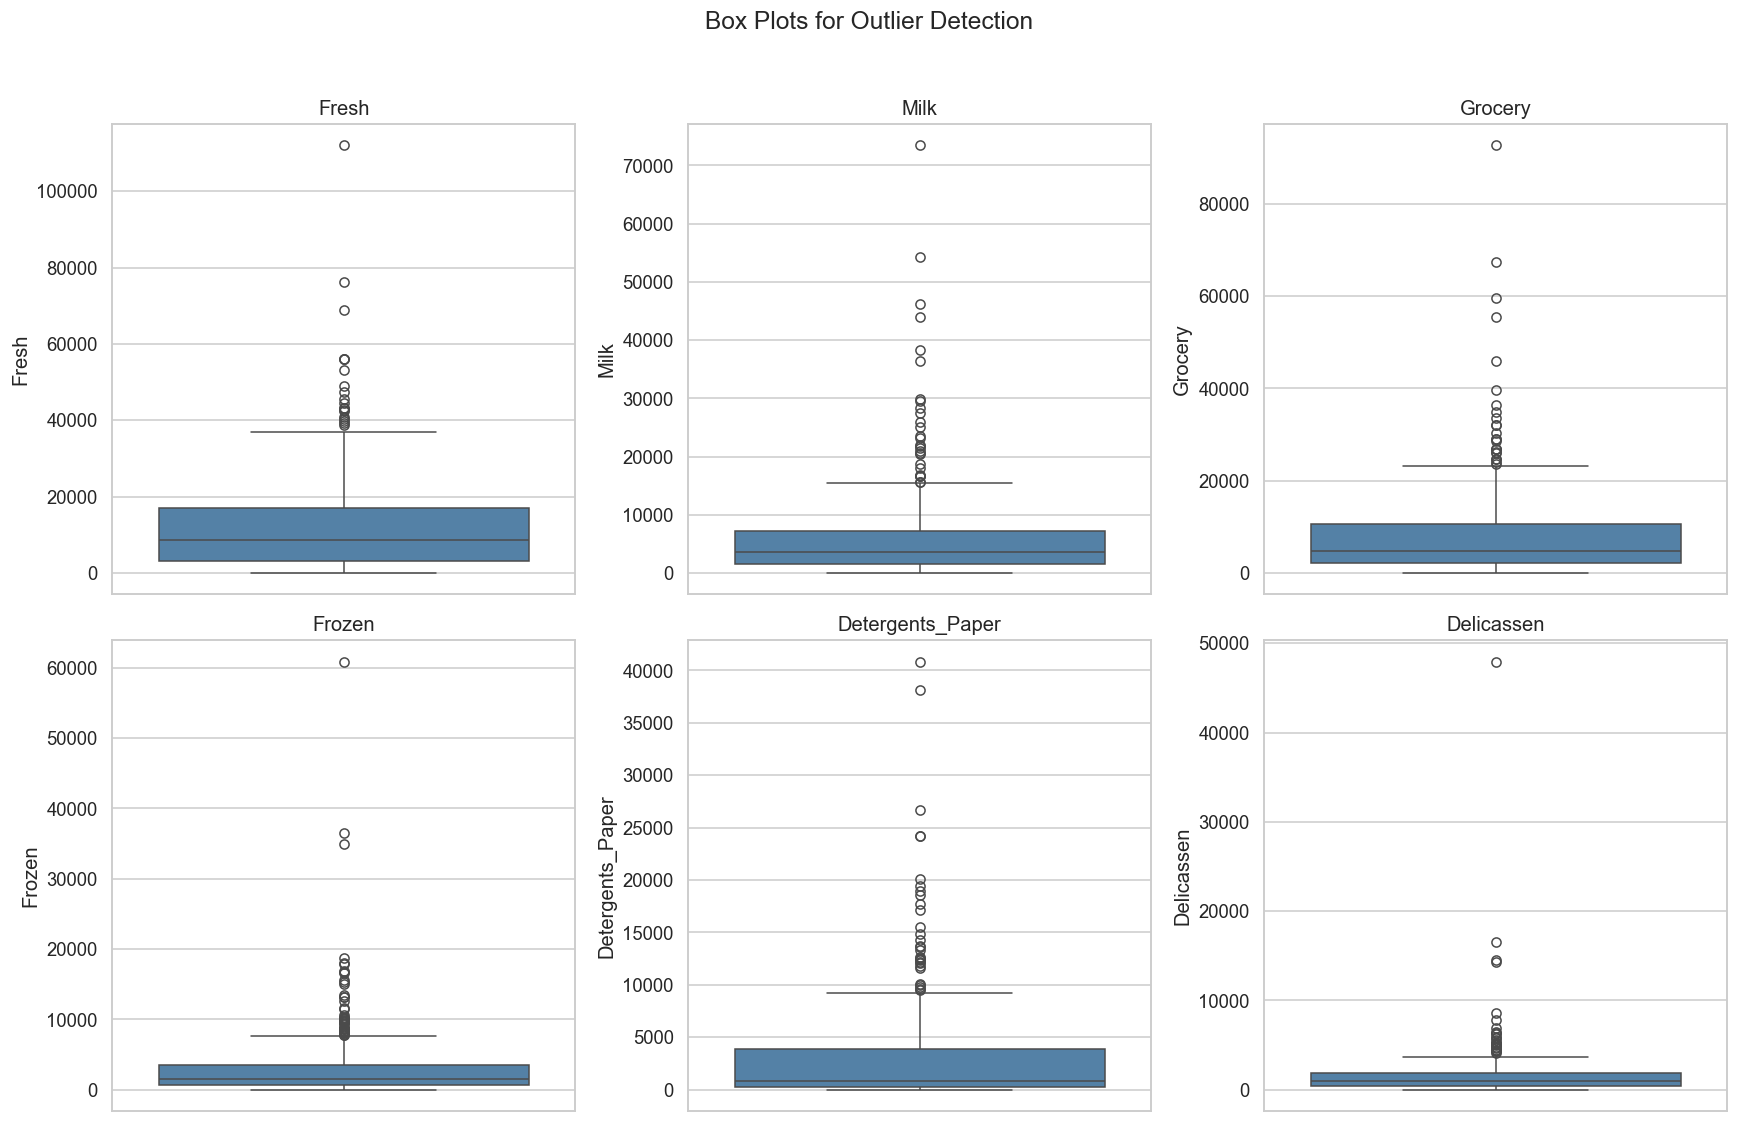

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(spending_cols):
    ax = axes[i // 3, i % 3]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Box Plots for Outlier Detection', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Correlation Heatmap

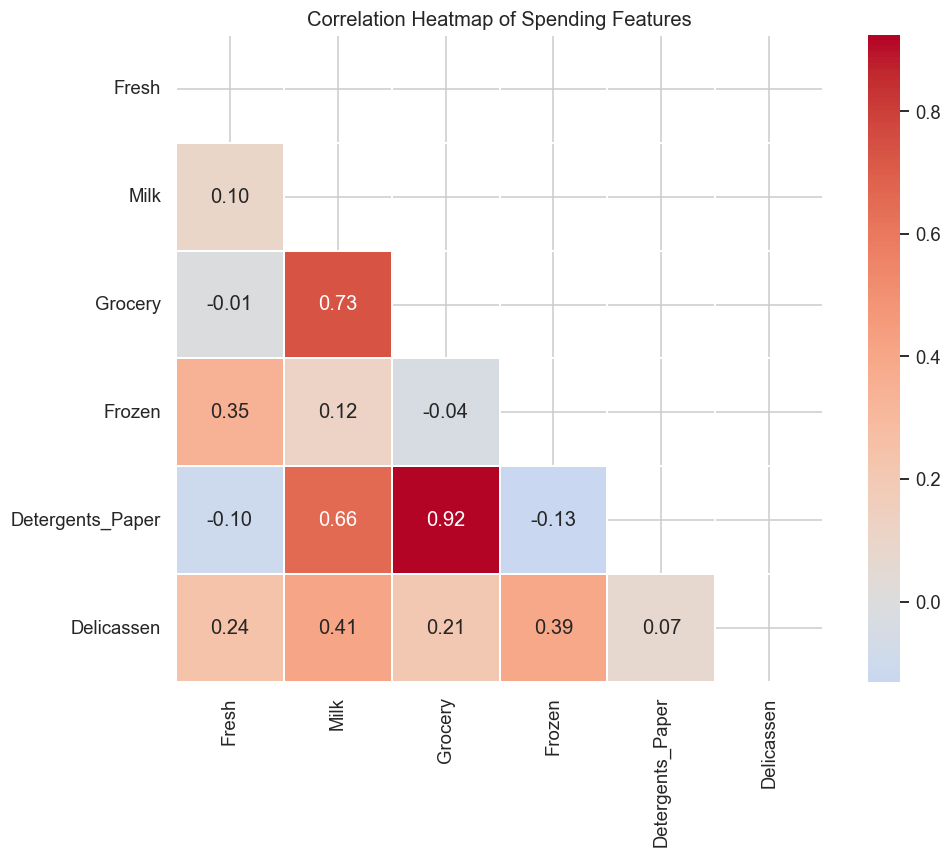

In [9]:
plt.figure(figsize=(10, 8))
corr = df[spending_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap of Spending Features')
plt.tight_layout()
plt.show()

**Observation:** Grocery and Detergents_Paper are strongly correlated (~0.92), and Milk correlates well with both. This suggests a "retail/household staples" purchasing pattern. Fresh and Frozen are more independent.

### 2.4 Pairplot (Colored by Channel)

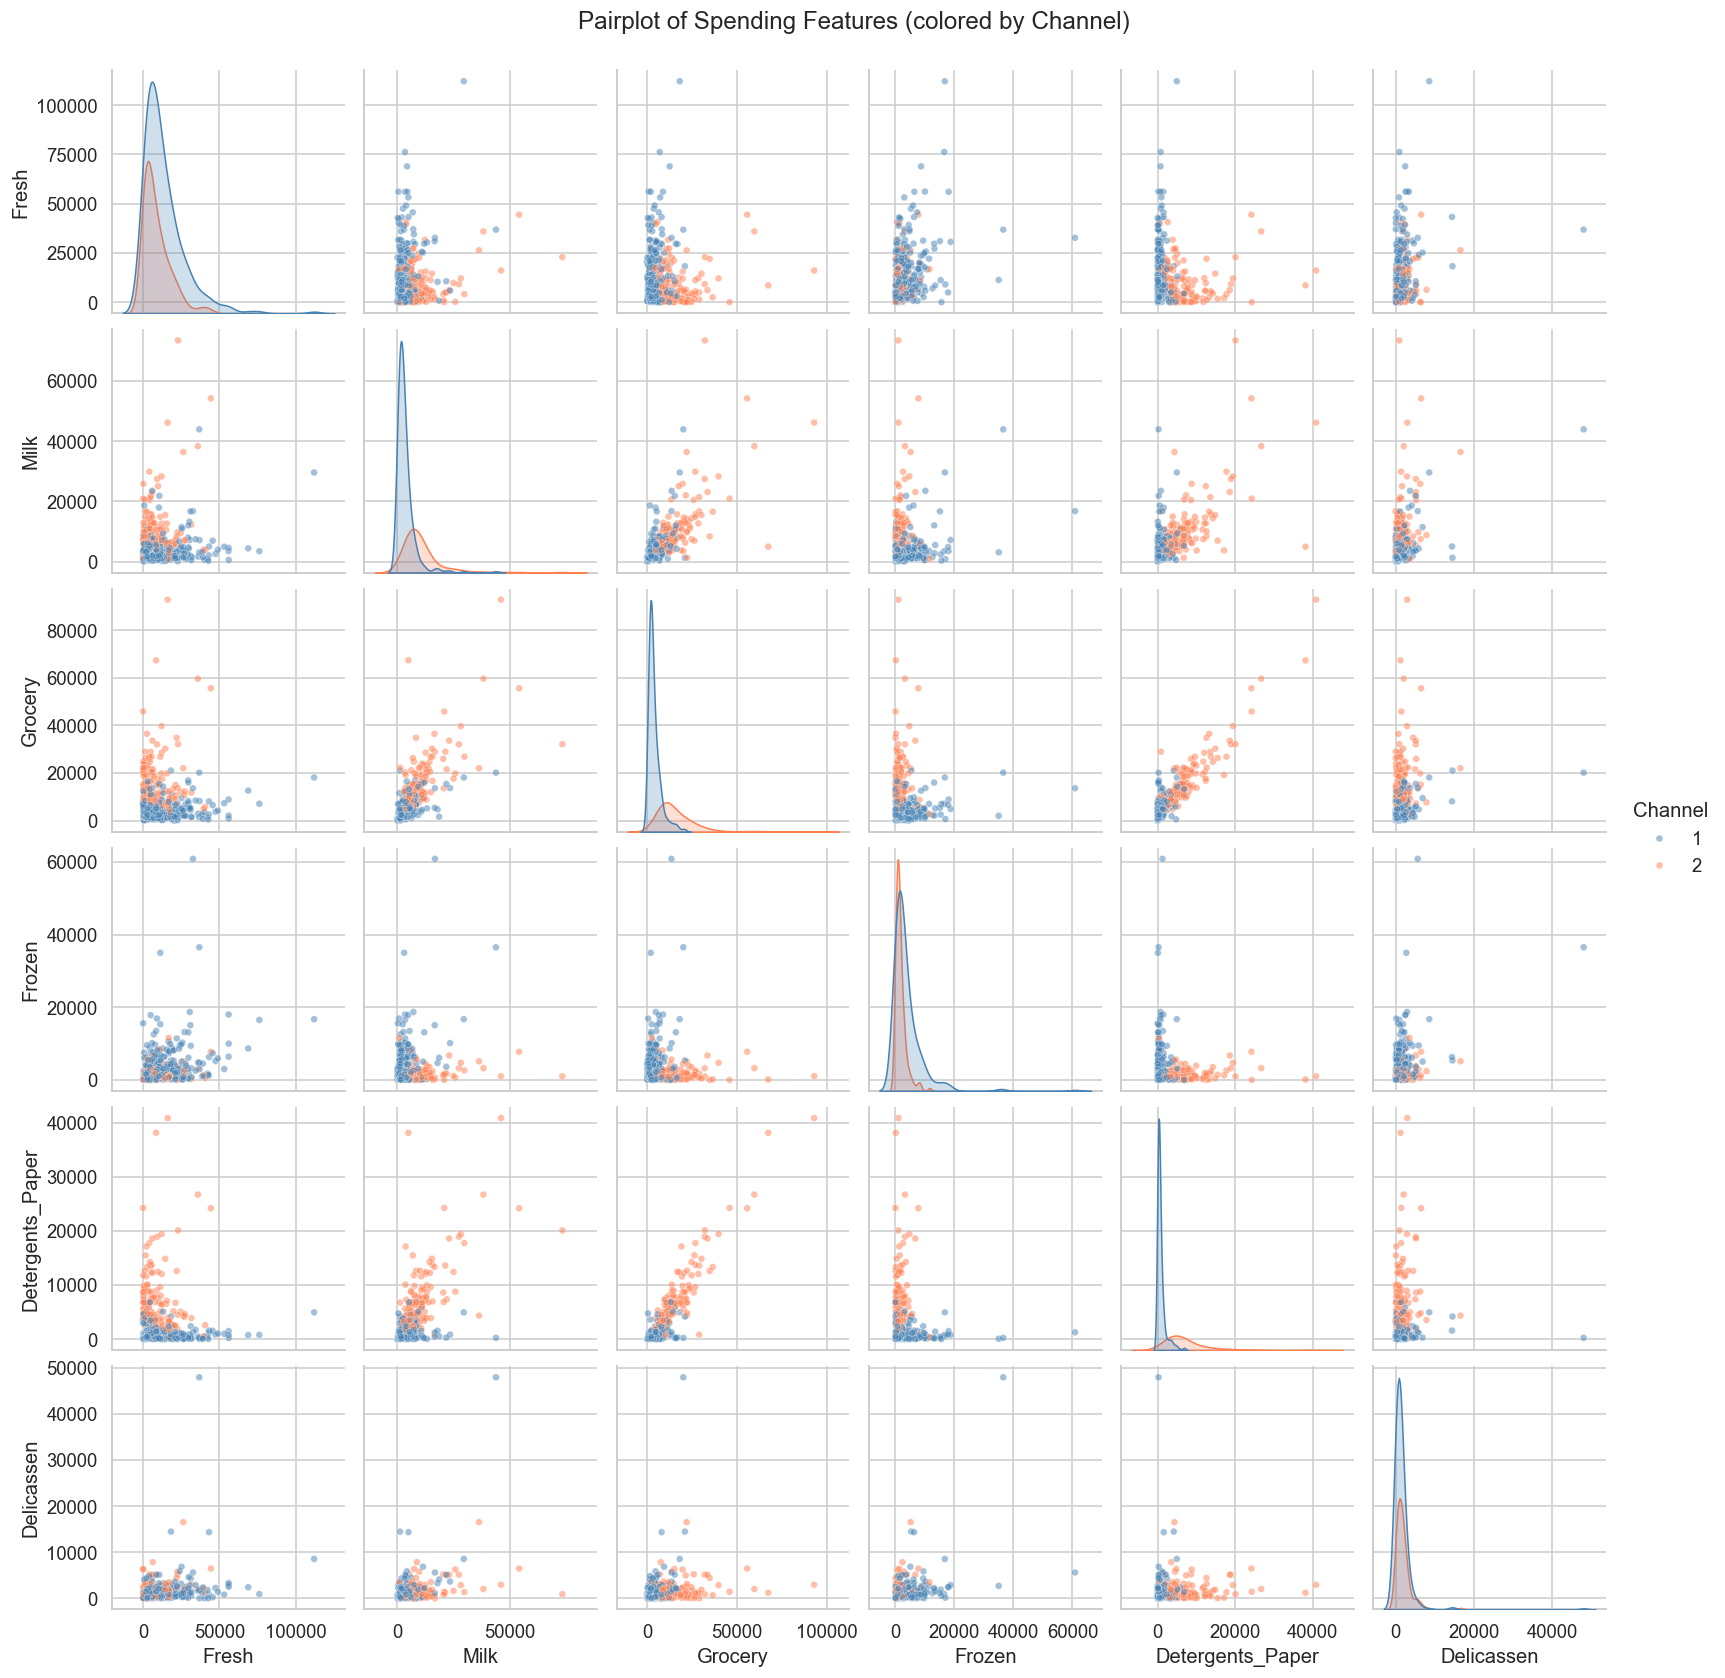

In [10]:
sns.pairplot(df[spending_cols + ['Channel']], hue='Channel',
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
             palette={1: 'steelblue', 2: 'coral'})
plt.suptitle('Pairplot of Spending Features (colored by Channel)', y=1.02)
plt.show()

### 2.5 Channel and Region Distributions

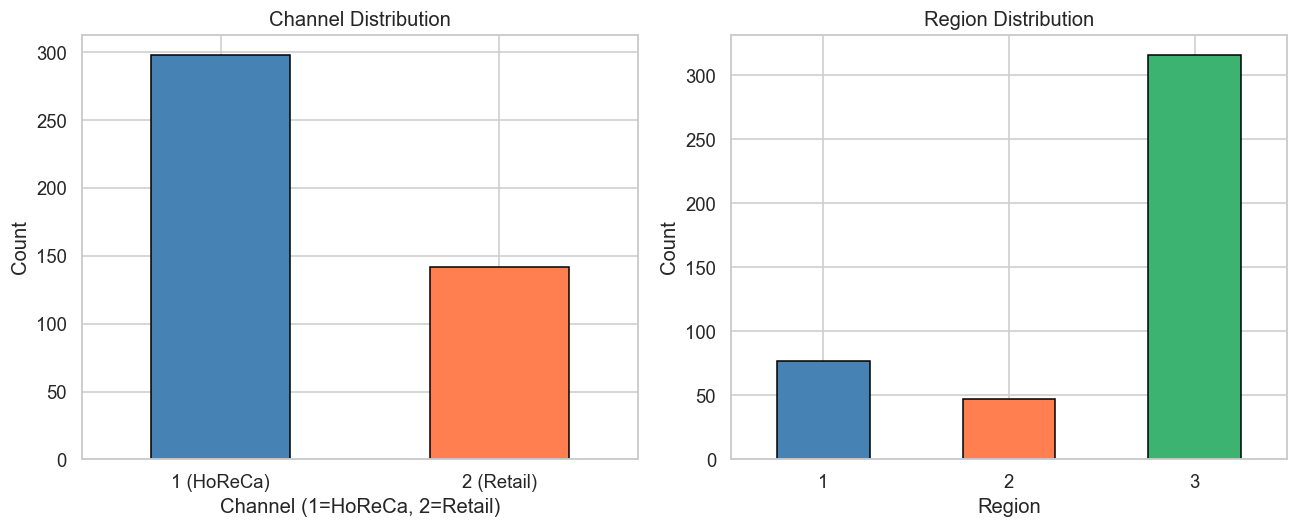

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Channel'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Channel Distribution')
axes[0].set_xlabel('Channel (1=HoReCa, 2=Retail)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['1 (HoReCa)', '2 (Retail)'], rotation=0)

df['Region'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
axes[1].set_title('Region Distribution')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['1', '2', '3'], rotation=0)

plt.tight_layout()
plt.show()

---
## 3 — Preprocessing

### 3.1 Log-Transform Skewed Features

In [12]:
df_log = df.copy()
for col in spending_cols:
    df_log[col] = np.log1p(df[col])

print('Skewness after log-transform:')
print(df_log[spending_cols].skew().round(2))

Skewness after log-transform:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


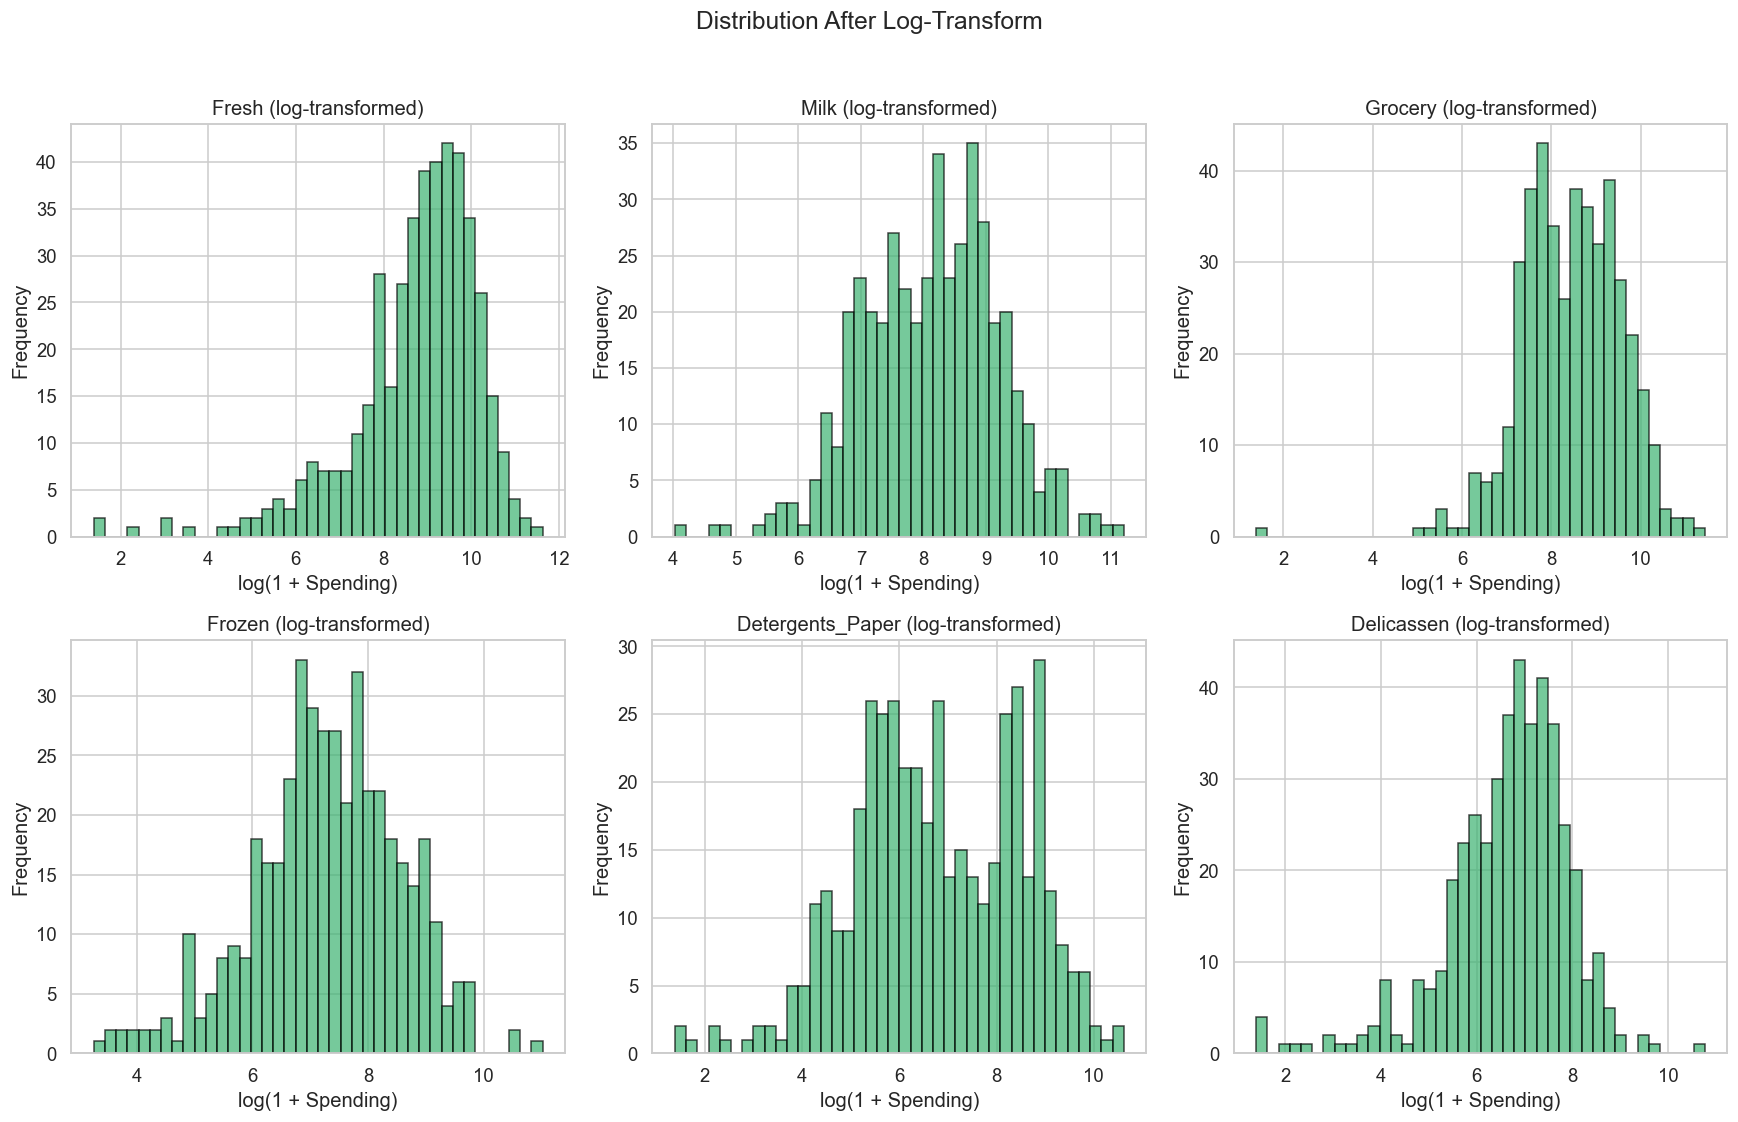

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(spending_cols):
    ax = axes[i // 3, i % 3]
    ax.hist(df_log[col], bins=40, edgecolor='black', alpha=0.7, color='mediumseagreen')
    ax.set_title(f'{col} (log-transformed)')
    ax.set_xlabel('log(1 + Spending)')
    ax.set_ylabel('Frequency')
plt.suptitle('Distribution After Log-Transform', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Feature Scaling

We standardize (zero mean, unit variance) using StandardScaler. This is critical for distance-based clustering algorithms (K-Means, DBSCAN). We use **spending features only** as the primary feature matrix (dropping Channel/Region to avoid trivially recovering those labels).

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(df_log[spending_cols])
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (440, 6)


---
## 4 — Clustering & Evaluation

### 4.1 K-Means Clustering

In [15]:
k_range = range(2, 11)
inertias = []
silhouette_scores_list = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouette_scores_list.append(sil)
    print(f'k={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.4f}')

k=2: Inertia=1844.1, Silhouette=0.2903
k=3: Inertia=1553.4, Silhouette=0.2594


k=4: Inertia=1386.9, Silhouette=0.1885
k=5: Inertia=1266.1, Silhouette=0.1916
k=6: Inertia=1174.8, Silhouette=0.2009


k=7: Inertia=1086.4, Silhouette=0.1958
k=8: Inertia=1028.5, Silhouette=0.1852


k=9: Inertia=973.1, Silhouette=0.1965
k=10: Inertia=932.0, Silhouette=0.1905


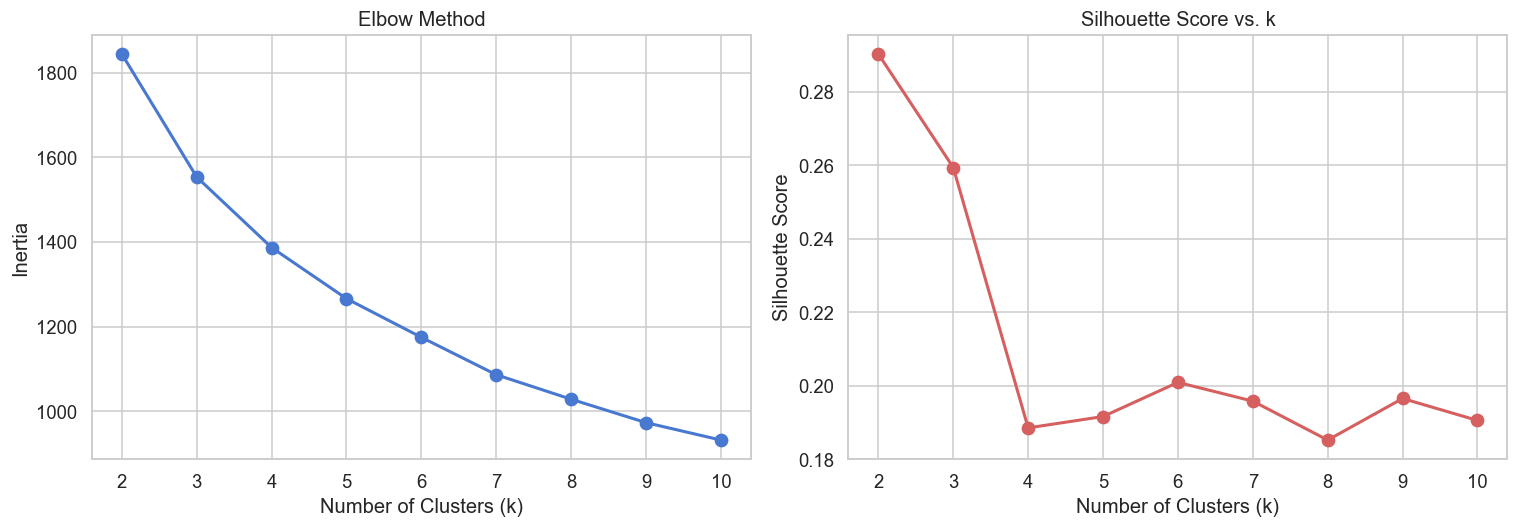

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores_list, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xticks(list(k_range))
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Observation:** The elbow plot shows a bend around k=2–3, and the silhouette score is typically highest at k=2. We proceed with both k=2 and k=3 for comparison.

In [17]:
km_2 = KMeans(n_clusters=2, n_init=10, random_state=SEED)
km_3 = KMeans(n_clusters=3, n_init=10, random_state=SEED)

labels_km2 = km_2.fit_predict(X)
labels_km3 = km_3.fit_predict(X)

print(f'K-Means (k=2) — Silhouette: {silhouette_score(X, labels_km2):.4f}')
print(f'K-Means (k=3) — Silhouette: {silhouette_score(X, labels_km3):.4f}')
print(f'\nCluster sizes (k=2): {np.bincount(labels_km2)}')
print(f'Cluster sizes (k=3): {np.bincount(labels_km3)}')

K-Means (k=2) — Silhouette: 0.2903
K-Means (k=3) — Silhouette: 0.2594

Cluster sizes (k=2): [252 188]
Cluster sizes (k=3): [ 80 147 213]


### 4.2 Hierarchical Clustering

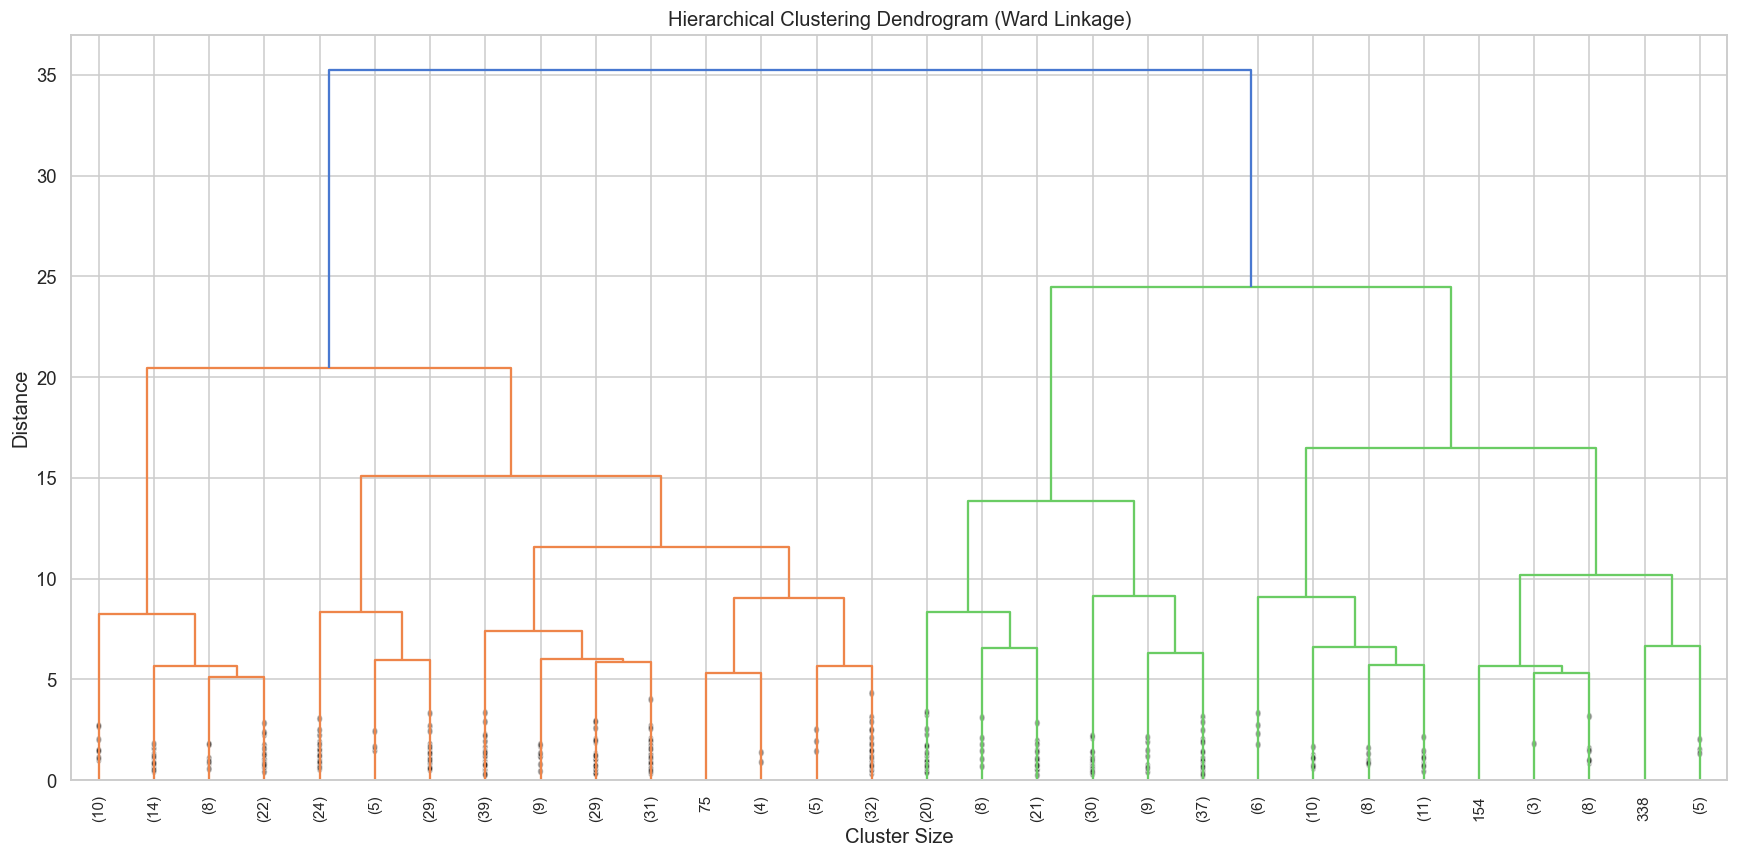

In [18]:
plt.figure(figsize=(16, 8))
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [19]:
agg_2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')

labels_agg2 = agg_2.fit_predict(X)
labels_agg3 = agg_3.fit_predict(X)

print(f'Agglomerative (k=2) — Silhouette: {silhouette_score(X, labels_agg2):.4f}')
print(f'Agglomerative (k=3) — Silhouette: {silhouette_score(X, labels_agg3):.4f}')
print(f'\nCluster sizes (k=2): {np.bincount(labels_agg2)}')
print(f'Cluster sizes (k=3): {np.bincount(labels_agg3)}')

Agglomerative (k=2) — Silhouette: 0.2585
Agglomerative (k=3) — Silhouette: 0.2547

Cluster sizes (k=2): [178 262]
Cluster sizes (k=3): [262  53 125]


### 4.3 DBSCAN

In [20]:
eps_values = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        sil = silhouette_score(X, labels_db) if n_clusters >= 2 else -1
        dbscan_results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
                               'n_noise': n_noise, 'silhouette': round(sil, 4)})

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df.to_string(index=False))

 eps  min_samples  n_clusters  n_noise  silhouette
0.50            3           8      396     -0.3993
0.50            5           1      435     -1.0000
0.50            7           0      440     -1.0000
0.50           10           0      440     -1.0000
0.75            3           9      218     -0.3170
0.75            5           4      281     -0.2599
0.75            7           3      323     -0.1475
0.75           10           3      385     -0.2741
1.00            3           6       91     -0.1616
1.00            5           1      124     -1.0000
1.00            7           2      134      0.0608
1.00           10           1      170     -1.0000
1.25            3           2       53      0.0712
1.25            5           1       70     -1.0000
1.25            7           1       74     -1.0000
1.25           10           1       84     -1.0000
1.50            3           2       35      0.2989
1.50            5           1       41     -1.0000
1.50            7           1  

In [21]:
best_row = dbscan_df[dbscan_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False).iloc[0]
print(f"Best DBSCAN: eps={best_row['eps']}, min_samples={int(best_row['min_samples'])}")
print(f"  Clusters: {int(best_row['n_clusters'])}, Noise: {int(best_row['n_noise'])}, Silhouette: {best_row['silhouette']}")

db_best = DBSCAN(eps=best_row['eps'], min_samples=int(best_row['min_samples']))
labels_dbscan = db_best.fit_predict(X)

Best DBSCAN: eps=1.5, min_samples=3
  Clusters: 2, Noise: 35, Silhouette: 0.2989


### 4.4 Comparison of Methods

In [22]:
comparison = pd.DataFrame({
    'Method': ['K-Means (k=2)', 'K-Means (k=3)',
               'Agglomerative (k=2)', 'Agglomerative (k=3)',
               f"DBSCAN (eps={best_row['eps']}, ms={int(best_row['min_samples'])})"],
    'Silhouette Score': [
        silhouette_score(X, labels_km2),
        silhouette_score(X, labels_km3),
        silhouette_score(X, labels_agg2),
        silhouette_score(X, labels_agg3),
        best_row['silhouette']
    ]
})
comparison = comparison.sort_values('Silhouette Score', ascending=False)
print(comparison.to_string(index=False))

                Method  Silhouette Score
DBSCAN (eps=1.5, ms=3)          0.298900
         K-Means (k=2)          0.290328
         K-Means (k=3)          0.259416
   Agglomerative (k=2)          0.258495
   Agglomerative (k=3)          0.254657


---
## 5 — Cluster Profiling & Communication

### 5.1 Assign Cluster Labels

In [23]:
# Use K-Means k=2 as primary result (highest silhouette expected)
df['Cluster'] = labels_km2

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    252
1    188
Name: count, dtype: int64


### 5.2 Cluster Profiles (Original Scale)

In [24]:
print('=== Mean Spending per Cluster ===')
cluster_means = df.groupby('Cluster')[spending_cols].mean().round(1)
print(cluster_means)
print()

print('=== Median Spending per Cluster ===')
cluster_medians = df.groupby('Cluster')[spending_cols].median().round(1)
print(cluster_medians)

=== Mean Spending per Cluster ===
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0        13973.1   2401.8   2918.7  3705.7             491.9      1038.0
1         9355.9  10346.4  14697.1  2222.5            6084.5      2177.4

=== Median Spending per Cluster ===
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                
0        10347.5  1871.0   2406.0  2225.0             327.5       749.5
1         5406.5  7690.5  11527.0  1061.5            4495.0      1388.5


In [25]:
print('=== Channel Distribution per Cluster ===')
print(pd.crosstab(df['Cluster'], df['Channel'], normalize='index').round(3))
print()

print('=== Region Distribution per Cluster ===')
print(pd.crosstab(df['Cluster'], df['Region'], normalize='index').round(3))

=== Channel Distribution per Cluster ===
Channel      1      2
Cluster              
0        0.968  0.032
1        0.287  0.713

=== Region Distribution per Cluster ===
Region       1      2      3
Cluster                     
0        0.190  0.111  0.698
1        0.154  0.101  0.745


### 5.3 Cluster Centroid Heatmap

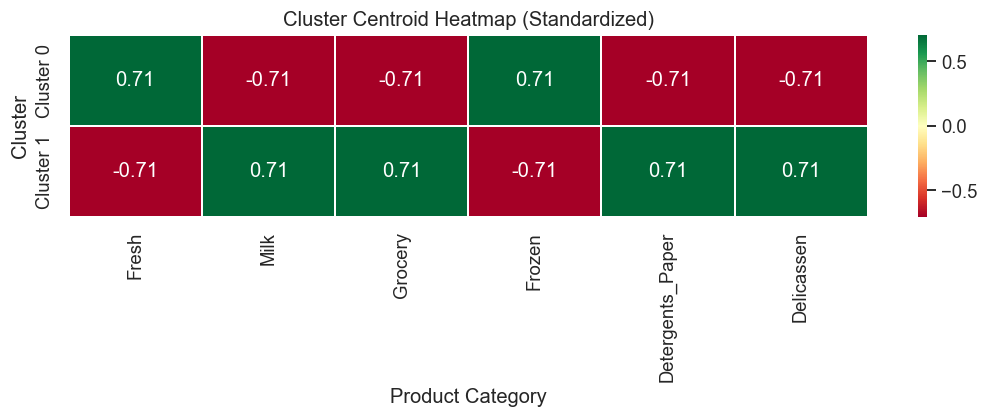

In [26]:
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_means_z, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=1, yticklabels=[f'Cluster {i}' for i in cluster_means_z.index])
plt.title('Cluster Centroid Heatmap (Standardized)')
plt.xlabel('Product Category')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

### 5.4 PCA Visualization

Explained variance ratio: [0.4408 0.2719]
Total variance explained: 0.7127


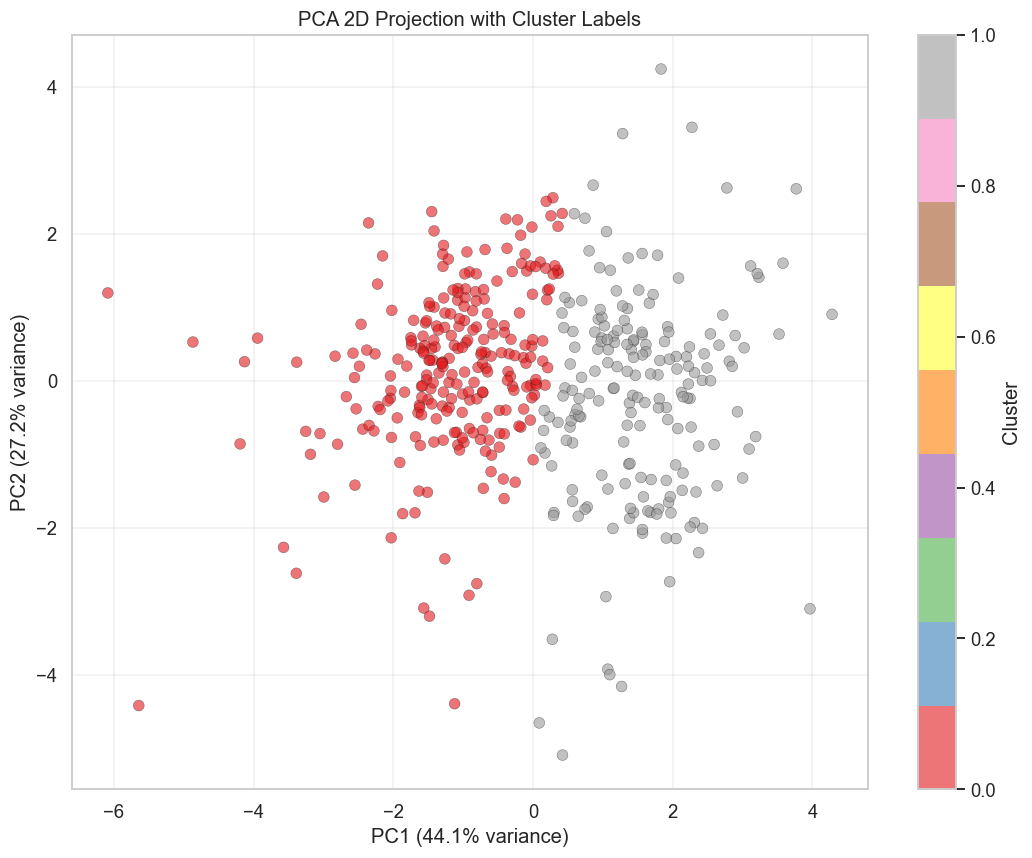

In [27]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.4f}')

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'],
                      cmap='Set1', alpha=0.6, s=50, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA 2D Projection with Cluster Labels')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 t-SNE Visualization

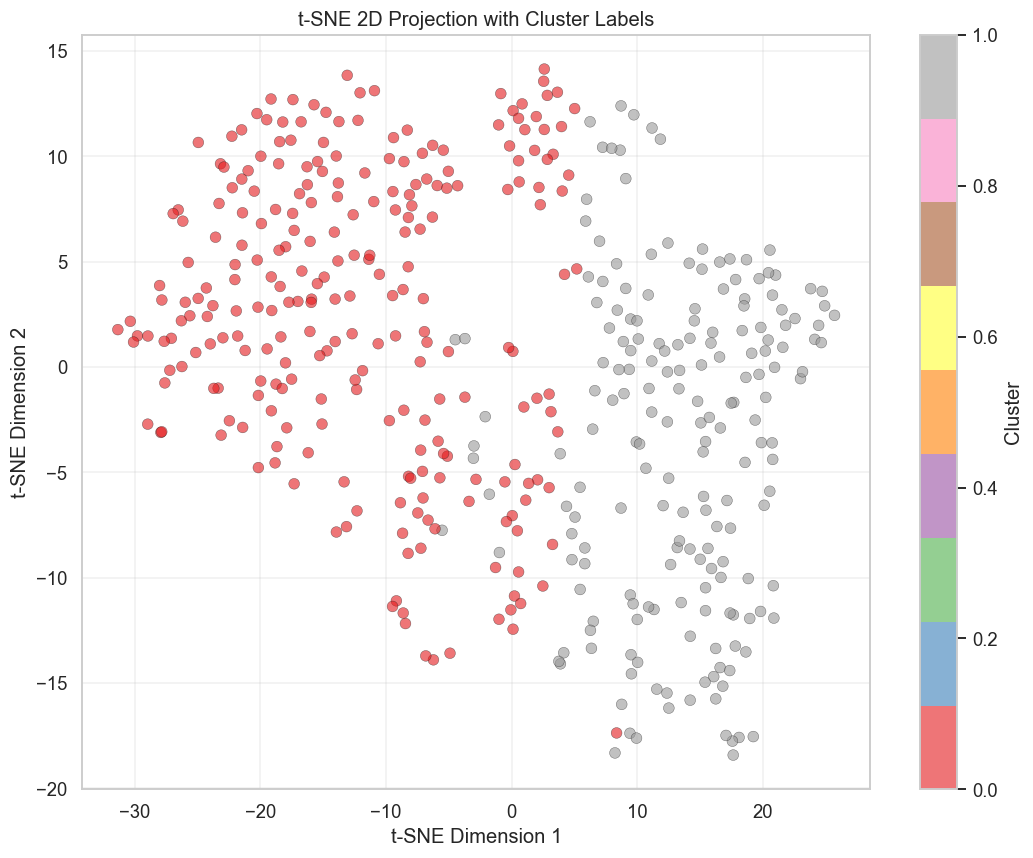

In [28]:
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['Cluster'],
                      cmap='Set1', alpha=0.6, s=50, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE 2D Projection with Cluster Labels')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 All Methods Side-by-Side (PCA Space)

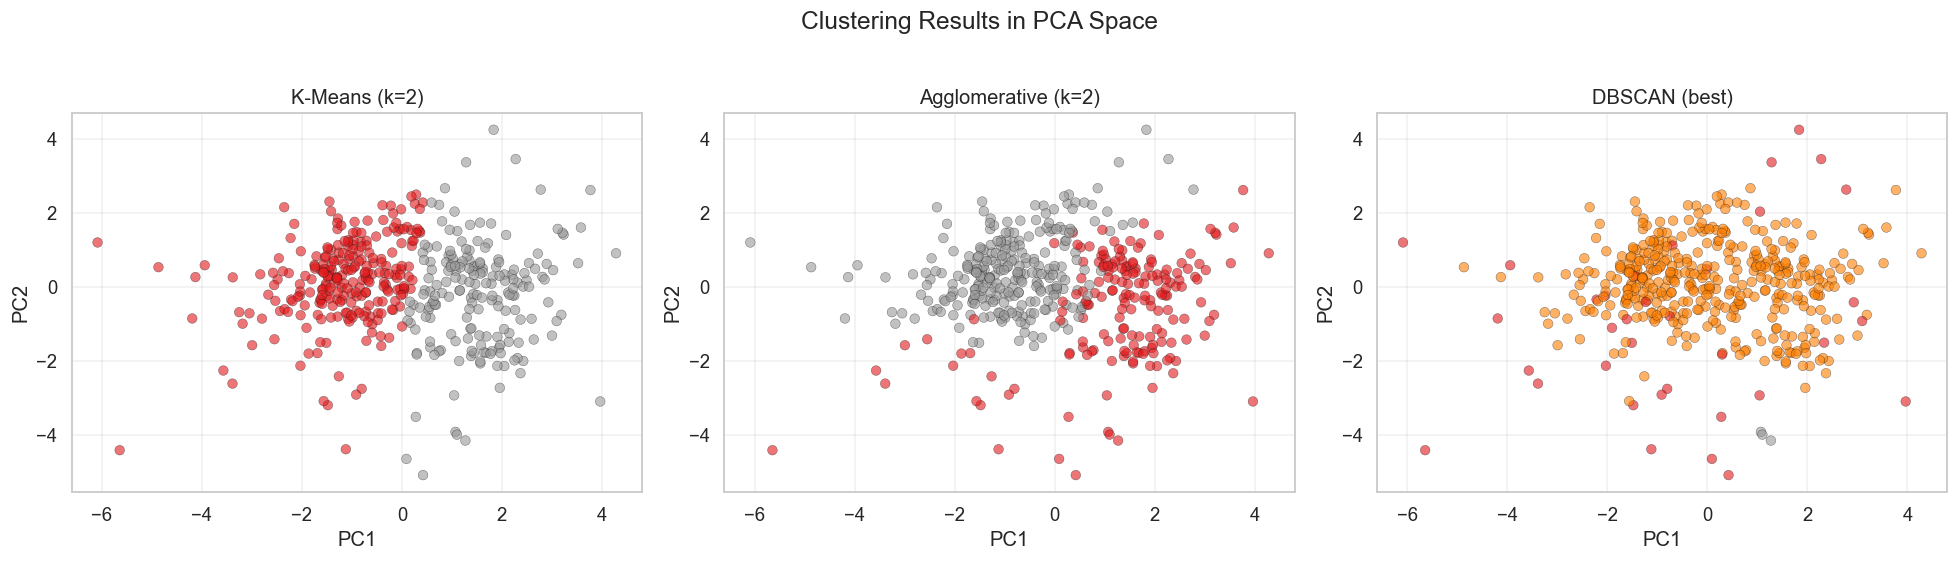

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, labels, title in zip(axes,
    [labels_km2, labels_agg2, labels_dbscan],
    ['K-Means (k=2)', 'Agglomerative (k=2)', 'DBSCAN (best)']):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                         cmap='Set1', alpha=0.6, s=40, edgecolors='k', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Clustering Results in PCA Space', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.7 Business Interpretation

**Cluster 0 — Fresh-focused (HoReCa) Customers:**
- Higher spending on **Fresh**, **Frozen**, and **Delicassen**
- Lower spending on **Grocery**, **Detergents_Paper**, and **Milk**
- Likely corresponds to Hotel/Restaurant/Cafe (Channel 1) customers buying perishables and specialty items in bulk
- *Business action:* Offer bulk discounts on fresh produce and frozen goods; ensure reliable cold-chain delivery

**Cluster 1 — Grocery-focused (Retail) Customers:**
- Higher spending on **Grocery**, **Detergents_Paper**, and **Milk**
- Lower spending on **Fresh** and **Frozen**
- Likely corresponds to Retail (Channel 2) customers stocking household staples
- *Business action:* Bundle deals on grocery + detergents; loyalty programs for repeat household-item purchases

---
## 6 — Conclusions

1. **Best algorithm:** K-Means with k=2 provides clean, interpretable segmentation that aligns closely with the Channel variable (HoReCa vs. Retail).
2. **Preprocessing matters:** Log-transforming the heavily skewed spending features and standardizing them significantly improved clustering quality.
3. **Two natural segments:** The wholesale customer base splits into (a) restaurant/cafe buyers focused on fresh and frozen goods, and (b) retail buyers focused on grocery and household products.
4. **Hierarchical clustering** produced similar results, validating the K-Means solution.
5. **DBSCAN** struggled with this dataset due to varying density across the feature space, though it can identify outlier customers as noise.
6. **Business value:** This segmentation enables targeted marketing, inventory optimization, and differentiated pricing strategies for each customer type.